# Azure Functions Invocation Trace 2021 分析与 Replay Schedule 生成

这个 notebook 用来分析 `AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt`。

目标：

1. 不一次性读入大文件，使用 `chunksize` 做 streaming analysis，避免 OOM。
2. 按 `(app, func)` 统计真实 Azure Functions invocation arrival pattern。
3. 为论文 background 提供 workload characterization：sparse、bursty、periodic、drift。
4. 从候选 `(app, func)` 中导出真实 arrival 的 replay schedule，后续 replay 到 SeBS-Flow 风格的 OpenWhisk workflow。

重要约定：

- Azure trace 不是 DAG trace，不要从 Azure 的 app/function 推断 workflow DAG。
- Azure trace 只作为 workflow entry arrival source。
- DAG 结构来自 `sebs_trip_booking`、`sebs_video`、`sebs_map_reduce`、`sebs_ml`。
- 当前文件中的 `end_timestamp` 和 `duration` 是 seconds，相对 trace 起点计时。
- 生成 OpenWhisk replay schedule 时会转换成 milliseconds。

In [14]:
from pathlib import Path
import os
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# 如果你希望手动指定 trace 文件，可以设置环境变量：
# export AZURE_TRACE_PATH=/path/to/AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt
TRACE_CANDIDATES = [
    Path(os.environ.get("AZURE_TRACE_PATH", "")) if os.environ.get("AZURE_TRACE_PATH") else None,
    Path("AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt"),
    Path("../AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt"),
    Path("../../AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt"),
]

AZURE_TRACE_PATH = None
for candidate in TRACE_CANDIDATES:
    if candidate is not None and candidate.exists():
        AZURE_TRACE_PATH = candidate.resolve()
        break

if AZURE_TRACE_PATH is None:
    raise FileNotFoundError("找不到 AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt，请设置 AZURE_TRACE_PATH。")

# 输出目录：放在当前工作目录的 data/azure_analysis 下。
OUTPUT_DIR = Path("data/azure_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 官方 schema。
SCHEMA = ["app", "func", "end_timestamp", "duration"]

print("AZURE_TRACE_PATH =", AZURE_TRACE_PATH)
print("file_size_MB     =", AZURE_TRACE_PATH.stat().st_size / 1024 / 1024)
print("OUTPUT_DIR       =", OUTPUT_DIR.resolve())

AZURE_TRACE_PATH = C:\Users\Administrator\Desktop\smiless-ad\AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt
file_size_MB     = 291.24099349975586
OUTPUT_DIR       = C:\Users\Administrator\Desktop\smiless-ad\stage2-openwhisk-prototype\notebooks\data\azure_analysis


## 1. 快速检查文件格式

这里只读取前几行，确认 header、字段类型和时间单位。

In [15]:
# 只读前 5 行，避免加载整个大文件。
preview = pd.read_csv(AZURE_TRACE_PATH, nrows=5)
preview

,app,func,end_timestamp,duration
0,7b2c43a2bc30f6bb438074df88b603d2cb982d3e7961de...,e3cdb48830f66eb8689cc0223514569a69812b77e6611e...,0.079491,0.078
1,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,337cd24a7d5fd5c92460faee4ebe6a186a0eb322bd17b7...,57.157860,57.154
2,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,48cc770d590d3c5a7691b3b4e9302f82ec3be5ddc2a037...,59.130478,59.125
3,f274d71de386ccc77e4ca74766dbc485461c3053059d47...,3d2aee54a133509f16fb636d74128c2adcfcac71c6dcef...,6.252541,6.236
4,7b2c43a2bc30f6bb438074df88b603d2cb982d3e7961de...,68bbfd828223a505d7917339f4656c5f33ff93225cdb9d...,0.066824,0.050


In [3]:
# 检查 timestamp 范围。这里 nrows 可以调大一点，但仍然不是全量读入。
small_sample = pd.read_csv(AZURE_TRACE_PATH, nrows=100_000)
print(small_sample.dtypes)
print("end_timestamp min/max:", small_sample["end_timestamp"].min(), small_sample["end_timestamp"].max())
print("duration min/max:", small_sample["duration"].min(), small_sample["duration"].max())
print("unique apps:", small_sample["app"].nunique(), "unique funcs:", small_sample["func"].nunique())

app               object
func              object
end_timestamp    float64
duration         float64
dtype: object
end_timestamp min/max: 0.0668239593505859 96734.44450497629
duration min/max: 0.0 563.175
unique apps: 48 unique funcs: 128


## 2. Streaming Reader

下面的函数会按 chunk 读取 CSV。每个 chunk 会：

- 保留 `app`, `func`, `end_timestamp`, `duration`
- 转成 numeric
- 过滤非法 duration
- 计算 `start_timestamp = end_timestamp - duration`

注意：`start_timestamp` 单位仍然是 seconds。

In [4]:
def read_chunks(path, chunksize=1_000_000):
    # 按 chunk 读取 Azure trace，避免一次性读入内存。
    return pd.read_csv(path, chunksize=chunksize)


def normalize_chunk(df):
    # 清洗一个 chunk，并计算 start_timestamp，单位是 seconds。
    df = df[SCHEMA].copy()
    df["app"] = df["app"].astype(str)
    df["func"] = df["func"].astype(str)
    df["end_timestamp"] = pd.to_numeric(df["end_timestamp"], errors="coerce")
    df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
    df = df.dropna(subset=["end_timestamp", "duration"])
    df = df[df["duration"] >= 0].copy()
    df["start_timestamp"] = df["end_timestamp"] - df["duration"]
    df = df[df["start_timestamp"] >= 0].copy()
    return df

## 3. 第一遍扫描：每个 `(app, func)` 的基础统计

这一步只聚合，不保存每条 invocation，所以内存开销可控。

输出：

- `azure2021_basic_function_summary.csv`

用途：

- 筛掉调用太少的函数。
- 找到 invocation count、duration、时间跨度合适的候选函数。

In [5]:
def scan_basic_stats(path, chunksize=1_000_000, max_chunks=None):
    parts = []
    total_rows = 0
    for chunk_idx, raw in enumerate(read_chunks(path, chunksize=chunksize), start=1):
        df = normalize_chunk(raw)
        total_rows += len(df)

        grouped = df.groupby(["app", "func"]).agg(
            invocations=("func", "size"),
            first_start_s=("start_timestamp", "min"),
            last_start_s=("start_timestamp", "max"),
            duration_sum_s=("duration", "sum"),
            duration_max_s=("duration", "max"),
        ).reset_index()
        parts.append(grouped)

        if chunk_idx % 5 == 0:
            print(f"chunk={chunk_idx}, processed_rows={total_rows:,}, partial_groups={len(grouped):,}")
        if max_chunks is not None and chunk_idx >= max_chunks:
            break

    combined = pd.concat(parts, ignore_index=True)
    summary = combined.groupby(["app", "func"]).agg(
        invocations=("invocations", "sum"),
        first_start_s=("first_start_s", "min"),
        last_start_s=("last_start_s", "max"),
        duration_sum_s=("duration_sum_s", "sum"),
        duration_max_s=("duration_max_s", "max"),
    ).reset_index()

    summary["span_minutes"] = np.maximum(1.0, (summary["last_start_s"] - summary["first_start_s"]) / 60.0)
    summary["mean_rate_per_min"] = summary["invocations"] / summary["span_minutes"]
    summary["mean_duration_ms"] = (summary["duration_sum_s"] / summary["invocations"]) * 1000.0
    summary["max_duration_ms"] = summary["duration_max_s"] * 1000.0
    summary = summary.sort_values("invocations", ascending=False).reset_index(drop=True)
    return summary


# 如果只是测试 notebook，可以先 max_chunks=2；正式分析用 None。
basic_summary = scan_basic_stats(AZURE_TRACE_PATH, chunksize=1_000_000, max_chunks=None)
basic_summary.to_csv(OUTPUT_DIR / "azure2021_basic_function_summary.csv", index=False)
print("function_pairs =", len(basic_summary))
basic_summary.head(20)

function_pairs = 424


,app,func,invocations,first_start_s,last_start_s,duration_sum_s,duration_max_s,span_minutes,mean_rate_per_min,mean_duration_ms,max_duration_ms
0,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,535667,6.429368e+03,1.209600e+06,888.325,1.470,20052.838752,26.712777,1.658353,1470.0
1,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f4...,212755,2.386248e+05,8.705725e+05,11162.546,11.025,10532.462104,20.199930,52.466668,11025.0
2,7958f89676bf3653f72cda8f38f6b3c0574dcae5169824...,cc5bb2108cc7daf53f9728ad21f661a8ef9c8b36284bac...,142856,3.932946e+04,1.209079e+06,110829.331,133.553,19495.819243,7.327520,775.811523,133553.0
3,62ed48c098820db02aa8e99ad41e5438e61334ba7b1618...,4753d9ffc8a362eadfb27498581969561c0ddbec725775...,124143,1.397299e+05,8.609913e+05,41357.160,126.233,12021.022073,10.327158,333.141297,126233.0
4,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,bd5be891d0d10fbc3c59215d5f8159ea496433bc41adba...,116130,2.372071e+05,8.742370e+05,3172.878,61.036,10617.164783,10.937948,27.321777,61036.0
5,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,89d488538f940c98367ff572230106d1089868bdd379d9...,76093,1.350627e+05,1.043298e+06,6592.036,30.025,15137.255524,5.026869,86.631306,30025.0
6,70b9cea7ca266637479483f517194c402dfe99b5fc2357...,30aa434528bc68ee07745ee7be3a0bdb33d58961fdc846...,71759,5.763566e+04,1.198900e+06,173702.306,305.768,19021.064217,3.772607,2420.634429,305768.0
7,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,b89efb5e9d1b7e5900ef441b098d4c8b01600af5e673a9...,63506,1.350580e+05,1.043301e+06,67996.421,127.991,15137.381017,4.195310,1070.708610,127991.0
8,5fb02cfeb979fec16df02d1ece227157238477b19fc6e3...,8e5f533dbf1092f56ac6c7542ef3bdec4661bd442c9b5e...,53263,1.803921e+03,1.209590e+06,6712.629,23.777,20129.768489,2.645982,126.027993,23777.0
9,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,eefb3a7b86d12c2676276a5dde28099ef6f546a60e5b78...,41333,1.350725e+05,1.043275e+06,11.564,0.687,15136.710400,2.730646,0.279776,687.0


## 4. 选择候选 `(app, func)` 做细粒度 time-series 分析

我们不对所有函数都建 time series，先筛调用量足够的候选函数，避免内存和计算开销过大。

In [6]:
# 可以根据实际数据规模调整。
MIN_INVOCATIONS = 200
MAX_CANDIDATES = 3000

candidate_basic = (
    basic_summary[basic_summary["invocations"] >= MIN_INVOCATIONS]
    .sort_values("invocations", ascending=False)
    .head(MAX_CANDIDATES)
    .copy()
)

candidate_basic["key"] = candidate_basic["app"] + "::" + candidate_basic["func"]
candidate_keys = set(candidate_basic["key"])

print("candidate functions =", len(candidate_keys))
candidate_basic.head(20)

candidate functions = 143


,app,func,invocations,first_start_s,last_start_s,duration_sum_s,duration_max_s,span_minutes,mean_rate_per_min,mean_duration_ms,max_duration_ms,key
0,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,535667,6.429368e+03,1.209600e+06,888.325,1.470,20052.838752,26.712777,1.658353,1470.0,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...
1,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f4...,212755,2.386248e+05,8.705725e+05,11162.546,11.025,10532.462104,20.199930,52.466668,11025.0,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...
2,7958f89676bf3653f72cda8f38f6b3c0574dcae5169824...,cc5bb2108cc7daf53f9728ad21f661a8ef9c8b36284bac...,142856,3.932946e+04,1.209079e+06,110829.331,133.553,19495.819243,7.327520,775.811523,133553.0,7958f89676bf3653f72cda8f38f6b3c0574dcae5169824...
3,62ed48c098820db02aa8e99ad41e5438e61334ba7b1618...,4753d9ffc8a362eadfb27498581969561c0ddbec725775...,124143,1.397299e+05,8.609913e+05,41357.160,126.233,12021.022073,10.327158,333.141297,126233.0,62ed48c098820db02aa8e99ad41e5438e61334ba7b1618...
4,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,bd5be891d0d10fbc3c59215d5f8159ea496433bc41adba...,116130,2.372071e+05,8.742370e+05,3172.878,61.036,10617.164783,10.937948,27.321777,61036.0,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...
5,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,89d488538f940c98367ff572230106d1089868bdd379d9...,76093,1.350627e+05,1.043298e+06,6592.036,30.025,15137.255524,5.026869,86.631306,30025.0,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...
6,70b9cea7ca266637479483f517194c402dfe99b5fc2357...,30aa434528bc68ee07745ee7be3a0bdb33d58961fdc846...,71759,5.763566e+04,1.198900e+06,173702.306,305.768,19021.064217,3.772607,2420.634429,305768.0,70b9cea7ca266637479483f517194c402dfe99b5fc2357...
7,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,b89efb5e9d1b7e5900ef441b098d4c8b01600af5e673a9...,63506,1.350580e+05,1.043301e+06,67996.421,127.991,15137.381017,4.195310,1070.708610,127991.0,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...
8,5fb02cfeb979fec16df02d1ece227157238477b19fc6e3...,8e5f533dbf1092f56ac6c7542ef3bdec4661bd442c9b5e...,53263,1.803921e+03,1.209590e+06,6712.629,23.777,20129.768489,2.645982,126.027993,23777.0,5fb02cfeb979fec16df02d1ece227157238477b19fc6e3...
9,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,eefb3a7b86d12c2676276a5dde28099ef6f546a60e5b78...,41333,1.350725e+05,1.043275e+06,11.564,0.687,15136.710400,2.730646,0.279776,687.0,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...


## 5. 第二遍扫描：候选函数的 minute-level arrival counts

这一步把 invocation-level trace 聚合到 1-minute bins。

为什么先用 1-minute bins？

- workload characterization 更稳定。
- 适合判断 sparse / bursty / periodic / drift。
- 后续 replay schedule 仍然会使用 invocation-level timestamps，不会丢掉真实到达时间。

In [7]:
def build_candidate_counts(path, candidate_keys, bin_seconds=60, chunksize=1_000_000, max_chunks=None):
    parts = []
    total_rows = 0
    for chunk_idx, raw in enumerate(read_chunks(path, chunksize=chunksize), start=1):
        df = normalize_chunk(raw)
        total_rows += len(df)
        df["key"] = df["app"] + "::" + df["func"]
        df = df[df["key"].isin(candidate_keys)].copy()
        if not df.empty:
            df["bin"] = np.floor(df["start_timestamp"] / bin_seconds).astype("int64")
            grouped = df.groupby(["key", "bin"]).size().reset_index(name="count")
            parts.append(grouped)

        if chunk_idx % 5 == 0:
            print(f"chunk={chunk_idx}, processed_rows={total_rows:,}, matched_rows={len(df):,}")
        if max_chunks is not None and chunk_idx >= max_chunks:
            break

    if not parts:
        return pd.DataFrame(columns=["key", "bin", "count"])
    out = pd.concat(parts, ignore_index=True)
    out = out.groupby(["key", "bin"], as_index=False)["count"].sum()
    return out


minute_counts = build_candidate_counts(AZURE_TRACE_PATH, candidate_keys, bin_seconds=60, chunksize=1_000_000, max_chunks=None)
minute_counts.to_csv(OUTPUT_DIR / "azure2021_candidate_minute_counts.csv", index=False)
print("minute_count rows =", len(minute_counts))
minute_counts.head()

minute_count rows = 206245


,key,bin,count
0,046b5f12d0ed300f37f207b6fb77b87e23fad3a7480d76...,13908,5
1,046b5f12d0ed300f37f207b6fb77b87e23fad3a7480d76...,13917,23
2,046b5f12d0ed300f37f207b6fb77b87e23fad3a7480d76...,13921,41
3,046b5f12d0ed300f37f207b6fb77b87e23fad3a7480d76...,13923,44
4,046b5f12d0ed300f37f207b6fb77b87e23fad3a7480d76...,13925,10


## 6. Workload Characterization 指标

这里计算几类可以写进论文 background 的指标：

- `zero_ratio`: 空窗口比例，越高越 sparse。
- `burst_score`: `max_per_min / active_mean_per_min`，越高越 bursty。
- `periodic_score`: 1h / 6h / 12h / 24h autocorrelation 的最大值。
- `drift_score`: 前半段与后半段调用量差异。
- `cv_per_min`: coefficient of variation。
- `fano_per_min`: variance-to-mean ratio。

In [8]:
def safe_autocorr(values, lag):
    if len(values) <= lag + 2:
        return np.nan
    x = values[:-lag]
    y = values[lag:]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def characterize_key(group):
    key = group["key"].iloc[0]
    group = group.sort_values("bin")
    first_bin = int(group["bin"].min())
    last_bin = int(group["bin"].max())
    span_bins = max(1, last_bin - first_bin + 1)
    active_bins = int(group["bin"].nunique())
    total = int(group["count"].sum())

    series = pd.Series(0.0, index=np.arange(first_bin, last_bin + 1))
    series.loc[group["bin"].to_numpy()] = group["count"].to_numpy(dtype=float)
    values = series.to_numpy(dtype=float)
    active_values = values[values > 0]

    mean = float(values.mean()) if len(values) else 0.0
    active_mean = float(active_values.mean()) if len(active_values) else 0.0
    max_count = int(values.max()) if len(values) else 0

    first_half = float(values[: len(values) // 2].sum())
    second_half = float(values[len(values) // 2 :].sum())
    drift_score = abs(second_half - first_half) / max(1.0, first_half + second_half)

    lag_scores = {
        "autocorr_1h": safe_autocorr(values, 60),
        "autocorr_6h": safe_autocorr(values, 360),
        "autocorr_12h": safe_autocorr(values, 720),
        "autocorr_24h": safe_autocorr(values, 1440),
    }
    valid_autocorr = [v for v in lag_scores.values() if not np.isnan(v)]
    periodic_score = max(valid_autocorr) if valid_autocorr else np.nan

    return {
        "key": key,
        "total_invocations": total,
        "first_bin": first_bin,
        "last_bin": last_bin,
        "span_minutes": span_bins,
        "active_minutes": active_bins,
        "zero_ratio": 1.0 - active_bins / span_bins,
        "mean_per_min": mean,
        "active_mean_per_min": active_mean,
        "max_per_min": max_count,
        "p95_per_min_all": float(np.quantile(values, 0.95)) if len(values) else 0.0,
        "p99_per_min_all": float(np.quantile(values, 0.99)) if len(values) else 0.0,
        "p95_per_min_active": float(np.quantile(active_values, 0.95)) if len(active_values) else 0.0,
        "p99_per_min_active": float(np.quantile(active_values, 0.99)) if len(active_values) else 0.0,
        "cv_per_min": float(np.std(values) / mean) if mean > 0 else np.nan,
        "fano_per_min": float(np.var(values) / mean) if mean > 0 else np.nan,
        "burst_score": max_count / max(1e-9, active_mean),
        "periodic_score": periodic_score,
        "drift_score": drift_score,
        **lag_scores,
    }


metrics = pd.DataFrame([characterize_key(g) for _, g in minute_counts.groupby("key")])
metrics[["app", "func"]] = metrics["key"].str.split("::", n=1, expand=True)
metrics = metrics.merge(candidate_basic[["key", "mean_duration_ms", "max_duration_ms"]], on="key", how="left")
metrics.to_csv(OUTPUT_DIR / "azure2021_candidate_characterization.csv", index=False)
metrics.sort_values("total_invocations", ascending=False).head(20)

,key,total_invocations,first_bin,last_bin,span_minutes,active_minutes,zero_ratio,mean_per_min,active_mean_per_min,max_per_min,p95_per_min_all,p99_per_min_all,p95_per_min_active,p99_per_min_active,cv_per_min,fano_per_min,burst_score,periodic_score,drift_score,autocorr_1h,autocorr_6h,autocorr_12h,autocorr_24h,app,func,mean_duration_ms,max_duration_ms
96,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,535667,107,20159,20053,8247,0.588740,26.712562,64.952953,252,110.00,125.00,120.00,130.00,1.492899,59.535531,3.879731,0.242322,0.120054,0.242322,0.068112,0.047287,0.051298,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.658353,1470.0
100,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,212755,3977,14509,10533,329,0.968765,20.198899,646.671733,1317,0.00,673.68,1190.60,1295.96,5.870464,696.101461,2.036582,0.085312,0.138897,0.085312,0.052256,-0.026033,0.019636,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f4...,52.466668,11025.0
57,7958f89676bf3653f72cda8f38f6b3c0574dcae5169824...,142856,655,20151,19497,5970,0.693799,7.327076,23.928978,189,45.00,83.00,74.00,110.31,2.365066,40.984259,7.898373,0.452243,0.009982,0.452243,-0.069560,-0.072160,0.040708,7958f89676bf3653f72cda8f38f6b3c0574dcae5169824...,cc5bb2108cc7daf53f9728ad21f661a8ef9c8b36284bac...,775.811523,133553.0
39,62ed48c098820db02aa8e99ad41e5438e61334ba7b1618...,124143,2328,14349,12022,2673,0.777658,10.326318,46.443322,504,60.00,108.79,103.40,229.12,2.642908,72.128939,10.851937,0.501518,0.673715,0.501518,0.349677,0.328258,0.133345,62ed48c098820db02aa8e99ad41e5438e61334ba7b1618...,4753d9ffc8a362eadfb27498581969561c0ddbec725775...,333.141297,126233.0
101,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,116130,3953,14570,10618,2029,0.808909,10.937088,57.235091,243,79.00,126.83,128.00,170.72,2.586308,73.158081,4.245647,0.760388,0.011590,0.760388,0.115538,-0.125512,0.206916,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,bd5be891d0d10fbc3c59215d5f8159ea496433bc41adba...,27.321777,61036.0
86,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,76093,2251,17388,15138,3943,0.739530,5.026622,19.298250,73,32.00,45.00,44.00,54.00,2.167642,23.618444,3.782726,0.642516,0.333211,0.642516,0.247727,0.104495,0.389800,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,89d488538f940c98367ff572230106d1089868bdd379d9...,86.631306,30025.0
46,70b9cea7ca266637479483f517194c402dfe99b5fc2357...,71759,960,19981,19022,357,0.981232,3.772421,201.005602,1302,0.00,55.79,656.40,732.32,11.196481,472.915255,6.477431,0.343950,0.464987,0.343950,0.293442,0.240854,0.230185,70b9cea7ca266637479483f517194c402dfe99b5fc2357...,30aa434528bc68ee07745ee7be3a0bdb33d58961fdc846...,2420.634429,305768.0
87,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,63506,2250,17388,15139,3824,0.747407,4.194861,16.607218,55,27.00,37.00,36.00,43.00,2.149449,19.380801,3.311813,0.652695,0.327969,0.652695,0.245061,0.109016,0.394725,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,b89efb5e9d1b7e5900ef441b098d4c8b01600af5e673a9...,1070.708610,127991.0
37,5fb02cfeb979fec16df02d1ece227157238477b19fc6e3...,53263,30,20159,20130,13352,0.336711,2.645951,3.989140,45,9.00,16.00,11.00,18.00,1.379656,5.036436,11.280626,0.637389,0.604153,0.637389,0.241278,0.105409,0.345532,5fb02cfeb979fec16df02d1ece227157238477b19fc6e3...,8e5f533dbf1092f56ac6c7542ef3bdec4661bd442c9b5e...,126.027993,23777.0
88,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,41333,2251,17387,15137,3864,0.744731,2.730594,10.696946,110,15.00,32.00,29.00,55.37,2.555452,17.831693,10.283309,0.371835,0.262042,0.371835,0.262981,0.213289,0.087817,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,c098bb74acb70a0ea1bce98a7090169f3be59a0758389a...,3.214018,3445.0


## 7. 按 workload 类型展示候选 trace

建议最终每类选 2 条：

- sparse
- bursty
- periodic
- mixed / drift

这样得到 8 条真实 Azure entry traces。

In [9]:
def show_candidates(df, sort_by, ascending=False, n=20, query=None):
    out = df.copy()
    if query:
        out = out.query(query).copy()
    cols = [
        "app", "func", "total_invocations", "span_minutes", "active_minutes",
        "zero_ratio", "mean_per_min", "active_mean_per_min", "max_per_min",
        "burst_score", "periodic_score", "drift_score", "mean_duration_ms"
    ]
    return out.sort_values(sort_by, ascending=ascending)[cols].head(n)


print("Sparse candidates")
display(show_candidates(metrics, "zero_ratio", ascending=False, query="total_invocations >= 200"))

print("Bursty candidates")
display(show_candidates(metrics, "burst_score", ascending=False, query="total_invocations >= 200 and active_minutes >= 10"))

print("Periodic candidates")
display(show_candidates(metrics, "periodic_score", ascending=False, query="total_invocations >= 500 and active_minutes >= 60"))

print("Drift / mixed candidates")
display(show_candidates(metrics, "drift_score", ascending=False, query="total_invocations >= 500"))

Sparse candidates


,app,func,total_invocations,span_minutes,active_minutes,zero_ratio,mean_per_min,active_mean_per_min,max_per_min,burst_score,periodic_score,drift_score,mean_duration_ms
92,a0ed6d33dc4622e0a557f45a85a64d359ca20c3e5888fe...,50242e50bdc20d4a9468e40a01658f98198029fef10071...,411,8433,5,0.999407,0.048737,82.200000,127,1.545012,-0.000203,0.454988,40.562044
78,8a9817064c66ff2f10fee3c19f644a7215c2a7614c4d60...,d1813c1d64f97bae544e030ca3f49b0fcdeefe06d976bc...,427,11522,8,0.999306,0.037060,53.375000,137,2.566745,0.437071,0.072600,561.388759
29,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,f781a67e39fc1fed1490db6798862355be27cdcf6b7b1d...,1545,14712,26,0.998233,0.105016,59.423077,309,5.200000,0.038643,0.453722,59.440129
141,fc4cdb6f79037e080699671080a27ffce1be75872c1cd3...,93002245db03177e592d0d08879dc855579cf7005733e2...,10218,10091,23,0.997721,1.012585,444.260870,1043,2.347720,-0.000794,0.224310,59.930417
40,62ed48c098820db02aa8e99ad41e5438e61334ba7b1618...,eafaad5acf5d68a876c0fe609024baa3e901700c7a19a8...,300,11881,31,0.997391,0.025250,9.677419,44,4.546667,0.177137,0.906667,8942.990000
28,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,559ffa91c0559a61d05c72dcece12c55d9201822967bbd...,201,14610,43,0.997057,0.013758,4.674419,18,3.850746,0.017738,0.402985,794.298507
110,b5450811f2226912d7c86164eeca69e414c0407a871525...,b5e597c31a20d9046084e9b5365a5151a3cb4a3634f0d2...,375,15870,54,0.996597,0.023629,6.944444,31,4.464000,0.000438,0.861333,4318.720000
80,8ef86af9762af3472a6e9ed3d521dc7b6eb8808476d3e1...,f8028773adc7867afcc54a2529032efd9c2ad7d46ba2cd...,3318,10497,42,0.995999,0.316090,79.000000,600,7.594937,0.137394,0.900542,10874.246835
27,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,32c6e2d6d752d3c30c43a9891766d887e0d25d38803445...,1259,14715,61,0.995855,0.085559,20.639344,76,3.682288,0.011262,0.459889,8139.768070
30,4f5eafc2b3d6ead5cc034aa58932c0020fac2dc1469f2c...,a1e92d7d2988e25cee3d876964f97909a5f56eb63b29ec...,310,6781,31,0.995428,0.045716,10.000000,10,1.000000,0.330324,0.225806,6311.193548


Bursty candidates


,app,func,total_invocations,span_minutes,active_minutes,zero_ratio,mean_per_min,active_mean_per_min,max_per_min,burst_score,periodic_score,drift_score,mean_duration_ms
44,6e42a4e8ea1df408e059ba37d0e04255fd8385235b3102...,7b80f728977125eae11985352adfe15333616e63075c3a...,24998,17274,656,0.962024,1.447146,38.106707,2324,60.986639,-0.000819,0.895752,82.046524
12,17c37a0fdd5d1932b755c0e6447137bc08fd524f455e14...,eb58570e8784a01a3ce5732980003c1c85f9028364b97e...,2531,17748,540,0.969574,0.142608,4.687037,189,40.323983,0.018470,0.566970,64.163967
26,4b22cc3e1988174edd67d91fd7a82a9977c1719601065e...,619caebdeff262e3b78a18e5c54a48f33f871f4210d576...,7908,20076,803,0.960002,0.393903,9.848070,115,11.677415,0.293980,0.970916,76.557410
37,5fb02cfeb979fec16df02d1ece227157238477b19fc6e3...,8e5f533dbf1092f56ac6c7542ef3bdec4661bd442c9b5e...,53263,20130,13352,0.336711,2.645951,3.989140,45,11.280626,0.637389,0.604153,126.027993
39,62ed48c098820db02aa8e99ad41e5438e61334ba7b1618...,4753d9ffc8a362eadfb27498581969561c0ddbec725775...,124143,12022,2673,0.777658,10.326318,46.443322,504,10.851937,0.501518,0.673715,333.141297
31,4fd9ef036fda3832e6bb4e57f1cc1395c248edddda334e...,50bb98931d9e1fbba7d4411188779a5fc732fb5eaefca0...,1065,18362,401,0.978161,0.058000,2.655860,28,10.542723,0.026934,0.406573,345.717371
88,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,c098bb74acb70a0ea1bce98a7090169f3be59a0758389a...,41333,15137,3864,0.744731,2.730594,10.696946,110,10.283309,0.371835,0.262042,3.214018
90,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,eefb3a7b86d12c2676276a5dde28099ef6f546a60e5b78...,41333,15137,3864,0.744731,2.730594,10.696946,110,10.283309,0.371837,0.262042,0.279776
0,046b5f12d0ed300f37f207b6fb77b87e23fad3a7480d76...,1a453e98528575570c5f1fe5801986a6b529120126f4a1...,3759,4418,135,0.969443,0.850837,27.844444,272,9.768555,0.014834,0.821229,11668.362596
82,938e7f49544b3293cd6cc7ec3e63e1751085cf5cb6a004...,6b2db95773685aa6d1f646584bbe1252579a0513df8057...,5295,19516,2282,0.883070,0.271316,2.320333,21,9.050425,0.035517,0.124835,307.218697


Periodic candidates


,app,func,total_invocations,span_minutes,active_minutes,zero_ratio,mean_per_min,active_mean_per_min,max_per_min,burst_score,periodic_score,drift_score,mean_duration_ms
139,f7bfe5bc8d2a37a5c15986fbfc2c477a746e866adcb966...,34f4775366e51728635af48df1a96d332cf1565eee069a...,6723,20158,6719,0.666683,0.333515,1.000595,2,1.998810,0.998883,0.000149,113.832664
140,f8a0e46efc7202b8d1ce896a4e0919f3b3e6d496c244a3...,8d17c87072bc8c74616a437e888ded668d9ee836df0c32...,3453,6899,3451,0.499783,0.500507,1.000580,2,1.998842,0.998249,0.000290,23.889661
135,db6be4a997f386b37c6246aaeecf81ab81562db84cf4c0...,9040b71f8a0325ba418c85bcefa3b19c02c781bed6284a...,1573,4714,1571,0.666737,0.333687,1.001273,2,1.997457,0.997198,0.000636,114.590591
11,17c37a0fdd5d1932b755c0e6447137bc08fd524f455e14...,c9f8e30e36d1aef62c10b3cfca6e289a93848a148d876d...,6614,13211,6606,0.499962,0.500643,1.001211,3,2.996371,0.997127,0.000302,17.510886
43,68d84244f6a3c212c69884d292b01a04ade8573f6c7b74...,ca8b2d1318a114f0efef6accb358b8cace2a39a81a2f78...,5500,16462,5488,0.666626,0.334103,1.002187,2,1.995636,0.997086,0.001818,120.360364
68,85479ef37b5dc75dd5aeca3bab499129b97a134dac5d74...,514a9bcff07d21b5580057748e55e78bb062e3001a01b7...,672,20131,672,0.966619,0.033381,1.000000,1,1.000000,0.993824,0.000000,1524.074405
125,b81ed828cb5e719288b0c64b3e27bcd36d78d32c4e4565...,f9a87a313332165438b226152befffb51d4e2b2b58f2cb...,1016,2045,1016,0.503178,0.496822,1.000000,1,1.000000,0.992972,0.007874,15.129921
116,b81ed828cb5e719288b0c64b3e27bcd36d78d32c4e4565...,61ef4300ea0cf81d4602407705b6f30e159f089deb27d5...,1016,2045,1016,0.503178,0.496822,1.000000,1,1.000000,0.992972,0.007874,13.856299
111,b81ed828cb5e719288b0c64b3e27bcd36d78d32c4e4565...,1b9cd666a58163d6558729dda564ad936f9ebfc808e1af...,1016,2045,1016,0.503178,0.496822,1.000000,1,1.000000,0.992972,0.007874,14.788386
112,b81ed828cb5e719288b0c64b3e27bcd36d78d32c4e4565...,1d1ecd1754b60ff559f7e83b3043fa902acf98d9b60d97...,1016,2045,1016,0.503178,0.496822,1.000000,1,1.000000,0.992972,0.007874,15.069882


Drift / mixed candidates


,app,func,total_invocations,span_minutes,active_minutes,zero_ratio,mean_per_min,active_mean_per_min,max_per_min,burst_score,periodic_score,drift_score,mean_duration_ms
75,85effaac4d59e8d2b8cce94be2794ccae809b5ee047010...,4ce7573ec82ce8a37bc9e2a3f45343b2fccf86faa0a8d1...,5341,49,49,0.000000,109.000000,109.000000,506,4.642202,NaN,0.972290,80134.088560
63,7e425fa87bc12971a26a9b5b31db5136f9a74bb0eda98f...,09bc1690a89815d06f88e3eb1835cca09c887387dcd39c...,1171,2191,22,0.989959,0.534459,53.227273,71,1.333903,-0.002001,0.970965,22.739539
26,4b22cc3e1988174edd67d91fd7a82a9977c1719601065e...,619caebdeff262e3b78a18e5c54a48f33f871f4210d576...,7908,20076,803,0.960002,0.393903,9.848070,115,11.677415,0.293980,0.970916,76.557410
45,6e42a4e8ea1df408e059ba37d0e04255fd8385235b3102...,bbb2ba81bf8692370f14cc8e0f0eba52442fec42b3d1b7...,6262,17013,128,0.992476,0.368071,48.921875,181,3.699776,0.187317,0.966145,51026.283136
93,a4a3c0390fad6c1ab8f2dc77113af81781edc24961772a...,0b1826008749cba0443c854732e217364d96c3f6d124b5...,3530,48,45,0.062500,73.541667,78.444444,338,4.308782,NaN,0.965439,92159.236827
81,8fccbc5264ff823b934d6651158d06d3589118fb9826a1...,b72d2c9bf5c14cb25b0dacea50c6eb59bdb7ab0ee0bd00...,1377,1265,19,0.984980,1.088538,72.473684,171,2.359477,-0.004103,0.954975,37004.926652
134,d399b29c39aafde69884d67ced0990a879c305854eca7e...,ae6f97c69d684b23e45ce195db1da6d3853004596e39b7...,7240,11490,317,0.972411,0.630113,22.839117,184,8.056354,0.005291,0.908840,551.384116
80,8ef86af9762af3472a6e9ed3d521dc7b6eb8808476d3e1...,f8028773adc7867afcc54a2529032efd9c2ad7d46ba2cd...,3318,10497,42,0.995999,0.316090,79.000000,600,7.594937,0.137394,0.900542,10874.246835
44,6e42a4e8ea1df408e059ba37d0e04255fd8385235b3102...,7b80f728977125eae11985352adfe15333616e63075c3a...,24998,17274,656,0.962024,1.447146,38.106707,2324,60.986639,-0.000819,0.895752,82.046524
35,5fb02cfeb979fec16df02d1ece227157238477b19fc6e3...,0ec5847f8ed19b3e77a42bc2ffc807dec44e29033c9f9b...,4763,12160,72,0.994079,0.391694,66.152778,481,7.271048,0.016624,0.845056,1473.558682


## 8. 手动选择用于 replay 的 `(app, func)`

从上面的候选表复制 `app` 和 `func`。

`workflow` 字段只是默认把这条 arrival trace 导出给哪个 workflow 使用；后续同一条 arrival trace 也可以 replay 到其他 workflow。

In [16]:
# TODO: 根据候选表手动填写。
# 每类建议先选 2 条，总共 8 条。
SELECTED_TRACES = [
    {
        "label": "sparse_0",
        "app": "4dd59aea96ab30b4156e2166b472206ff912315495a3c4f713fbdc240d06b9b0",
        "func": "f781a67e39fc1fed1490db6798862355be27cdcf6b7b1d87a38b334db073659c",
        "workload_type": "sparse",
        "workflow": "sebs_trip_booking",
    },
    {
        "label": "sparse_1",
        "app": "5fb02cfeb979fec16df02d1ece227157238477b19fc6e37554e2e2af6018d3ba",
        "func": "0ec5847f8ed19b3e77a42bc2ffc807dec44e29033c9f9bf2661908b8680995ed",
        "workload_type": "sparse",
        "workflow": "sebs_trip_booking",
    },
    {
        "label": "bursty_0",
        "app": "6e42a4e8ea1df408e059ba37d0e04255fd8385235b310265a57091132d760a65",
        "func": "7b80f728977125eae11985352adfe15333616e63075c3a14e057745b550b25ac",
        "workload_type": "bursty",
        "workflow": "sebs_video",
    },
    {
        "label": "bursty_1",
        "app": "17c37a0fdd5d1932b755c0e6447137bc08fd524f455e14fdac414f584de08dc5",
        "func": "eb58570e8784a01a3ce5732980003c1c85f9028364b97ed1f1a6d1384507b8c2",
        "workload_type": "bursty",
        "workflow": "sebs_video",
    },
    {
        "label": "periodic_0",
        "app": "f7bfe5bc8d2a37a5c15986fbfc2c477a746e866adcb9663f9df7535b61c3eb9b",
        "func": "34f4775366e51728635af48df1a96d332cf1565eee069a0030f12966ae760274",
        "workload_type": "periodic",
        "workflow": "sebs_map_reduce",
    },
    {
        "label": "periodic_1",
        "app": "f8a0e46efc7202b8d1ce896a4e0919f3b3e6d496c244a3a4c5b74ef135416264",
        "func": "8d17c87072bc8c74616a437e888ded668d9ee836df0c328c2347331a1313c096",
        "workload_type": "periodic",
        "workflow": "sebs_map_reduce",
    },
    {
        "label": "drift_0",
        "app": "4b22cc3e1988174edd67d91fd7a82a9977c1719601065e5740d54074a6910170",
        "func": "619caebdeff262e3b78a18e5c54a48f33f871f4210d57657e7fe4ce847e5a22c",
        "workload_type": "drift",
        "workflow": "sebs_ml",
    },
    {
        "label": "mixed_0",
        "app": "d27353c8ad7c924a609457eb5a53333a7e519bcf8efd884dcca7ffb908ca3fa6",
        "func": "905e6674359f6487df567fa2c8ca1c8641e7740f2e32d9fd26e9fe1ff7a4670d",
        "workload_type": "mixed",
        "workflow": "sebs_ml",
    },
]


selected_df = pd.DataFrame(SELECTED_TRACES)
selected_df

,label,app,func,workload_type,workflow
0,sparse_0,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,f781a67e39fc1fed1490db6798862355be27cdcf6b7b1d...,sparse,sebs_trip_booking
1,sparse_1,5fb02cfeb979fec16df02d1ece227157238477b19fc6e3...,0ec5847f8ed19b3e77a42bc2ffc807dec44e29033c9f9b...,sparse,sebs_trip_booking
2,bursty_0,6e42a4e8ea1df408e059ba37d0e04255fd8385235b3102...,7b80f728977125eae11985352adfe15333616e63075c3a...,bursty,sebs_video
3,bursty_1,17c37a0fdd5d1932b755c0e6447137bc08fd524f455e14...,eb58570e8784a01a3ce5732980003c1c85f9028364b97e...,bursty,sebs_video
4,periodic_0,f7bfe5bc8d2a37a5c15986fbfc2c477a746e866adcb966...,34f4775366e51728635af48df1a96d332cf1565eee069a...,periodic,sebs_map_reduce
5,periodic_1,f8a0e46efc7202b8d1ce896a4e0919f3b3e6d496c244a3...,8d17c87072bc8c74616a437e888ded668d9ee836df0c32...,periodic,sebs_map_reduce
6,drift_0,4b22cc3e1988174edd67d91fd7a82a9977c1719601065e...,619caebdeff262e3b78a18e5c54a48f33f871f4210d576...,drift,sebs_ml
7,mixed_0,d27353c8ad7c924a609457eb5a53333a7e519bcf8efd88...,905e6674359f6487df567fa2c8ca1c8641e7740f2e32d9...,mixed,sebs_ml


## 9. 加载某个 `(app, func)` 的 invocation-level timestamps

这里会重新 streaming 扫描大文件，但只保留选中的 `(app, func)`。

输出 schedule 时会把 seconds 转成 milliseconds。

In [17]:
def load_invocations_for_key(path, app, func, chunksize=1_000_000, max_rows=None):
    parts = []
    total = 0
    app = str(app)
    func = str(func)
    for raw in read_chunks(path, chunksize=chunksize):
        df = normalize_chunk(raw)
        df = df[(df["app"] == app) & (df["func"] == func)].copy()
        if df.empty:
            continue
        parts.append(df)
        total += len(df)
        if max_rows is not None and total >= max_rows:
            break
    if not parts:
        return pd.DataFrame(columns=SCHEMA + ["start_timestamp"])
    out = pd.concat(parts, ignore_index=True).sort_values("start_timestamp").reset_index(drop=True)
    if max_rows is not None:
        out = out.head(max_rows).copy()
    return out


def make_replay_schedule(invocations, workflow_name, source_label, speedup=1.0, max_invocations=None, min_interarrival_ms=0):
    # 把真实 Azure invocation timestamps 转成 OpenWhisk replay schedule。
    df = invocations.sort_values("start_timestamp").copy()
    if max_invocations is not None:
        df = df.head(max_invocations).copy()
    if df.empty:
        return pd.DataFrame()

    source_start_s = float(df["start_timestamp"].min())
    offsets_ms = ((df["start_timestamp"] - source_start_s) * 1000.0 / max(1e-9, speedup)).round().astype("int64").to_numpy()

    # 可选保护：限制最小 inter-arrival，避免本地 OpenWhisk 被真实高峰直接打爆。
    if min_interarrival_ms and min_interarrival_ms > 0:
        adjusted = []
        prev = None
        for off in offsets_ms:
            if prev is None:
                current = int(off)
            else:
                current = max(int(off), prev + int(min_interarrival_ms))
            adjusted.append(current)
            prev = current
        offsets_ms = np.array(adjusted, dtype="int64")

    schedule = pd.DataFrame({
        "workflow_name": workflow_name,
        "index": np.arange(len(df), dtype=int),
        "target_offset_ms": offsets_ms,
        "source_label": source_label,
        "source_app": df["app"].astype(str).to_numpy(),
        "source_func": df["func"].astype(str).to_numpy(),
        "source_start_s": df["start_timestamp"].to_numpy(),
        "source_end_s": df["end_timestamp"].to_numpy(),
        "source_duration_ms": (df["duration"] * 1000.0).round().astype("int64").to_numpy(),
    })
    return schedule

## 10. 导出 Replay Schedule

参数说明：

- `SPEEDUP`: 时间压缩倍率。`1.0` 表示保持原始时间间隔；`10.0` 表示压缩 10 倍。
- `MAX_INVOCATIONS_PER_TRACE`: 每条 trace 最多导出多少 invocation。
- `MIN_INTERARRIVAL_MS`: 最小 arrival 间隔保护，避免本地 OpenWhisk 触发 rate limit。

正式实验中必须记录这些参数。

In [18]:
SPEEDUP = 1.0
MAX_INVOCATIONS_PER_TRACE = 300
MIN_INTERARRIVAL_MS = 0

schedule_paths = []
for item in SELECTED_TRACES:
    inv = load_invocations_for_key(
        AZURE_TRACE_PATH,
        item["app"],
        item["func"],
        max_rows=MAX_INVOCATIONS_PER_TRACE,
    )
    print(item["label"], "invocations loaded =", len(inv))

    schedule = make_replay_schedule(
        inv,
        workflow_name=item.get("workflow", "sebs_video"),
        source_label=item["label"],
        speedup=SPEEDUP,
        max_invocations=MAX_INVOCATIONS_PER_TRACE,
        min_interarrival_ms=MIN_INTERARRIVAL_MS,
    )

    out_path = OUTPUT_DIR / f"schedule_{item['label']}_{item.get('workflow', 'workflow')}.csv"
    schedule.to_csv(out_path, index=False)
    schedule_paths.append(out_path)
    display(schedule.head())
    print("wrote", out_path)

schedule_paths

sparse_0 invocations loaded = 300


,workflow_name,index,target_offset_ms,source_label,source_app,source_func,source_start_s,source_end_s,source_duration_ms
0,sebs_trip_booking,0,0,sparse_0,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,f781a67e39fc1fed1490db6798862355be27cdcf6b7b1d...,211293.860174,211297.341174,3481
1,sebs_trip_booking,1,3432,sparse_0,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,f781a67e39fc1fed1490db6798862355be27cdcf6b7b1d...,211297.291913,211297.637913,346
2,sebs_trip_booking,2,3798,sparse_0,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,f781a67e39fc1fed1490db6798862355be27cdcf6b7b1d...,211297.657697,211297.755697,98
3,sebs_trip_booking,3,3807,sparse_0,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,f781a67e39fc1fed1490db6798862355be27cdcf6b7b1d...,211297.666694,211297.856694,190
4,sebs_trip_booking,4,3916,sparse_0,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,f781a67e39fc1fed1490db6798862355be27cdcf6b7b1d...,211297.776254,211297.859254,83


wrote data\azure_analysis\schedule_sparse_0_sebs_trip_booking.csv
sparse_1 invocations loaded = 300


,workflow_name,index,target_offset_ms,source_label,source_app,source_func,source_start_s,source_end_s,source_duration_ms
0,sebs_trip_booking,0,0,sparse_1,5fb02cfeb979fec16df02d1ece227157238477b19fc6e3...,0ec5847f8ed19b3e77a42bc2ffc807dec44e29033c9f9b...,404326.125851,404326.547851,422
1,sebs_trip_booking,1,125,sparse_1,5fb02cfeb979fec16df02d1ece227157238477b19fc6e3...,0ec5847f8ed19b3e77a42bc2ffc807dec44e29033c9f9b...,404326.251327,404326.719327,468
2,sebs_trip_booking,2,177,sparse_1,5fb02cfeb979fec16df02d1ece227157238477b19fc6e3...,0ec5847f8ed19b3e77a42bc2ffc807dec44e29033c9f9b...,404326.302528,404326.724528,422
3,sebs_trip_booking,3,1002,sparse_1,5fb02cfeb979fec16df02d1ece227157238477b19fc6e3...,0ec5847f8ed19b3e77a42bc2ffc807dec44e29033c9f9b...,404327.128026,404327.539026,411
4,sebs_trip_booking,4,3990,sparse_1,5fb02cfeb979fec16df02d1ece227157238477b19fc6e3...,0ec5847f8ed19b3e77a42bc2ffc807dec44e29033c9f9b...,404330.115753,404330.356753,241


wrote data\azure_analysis\schedule_sparse_1_sebs_trip_booking.csv
bursty_0 invocations loaded = 300


...

,workflow_name,index,target_offset_ms,source_label,source_app,source_func,source_start_s,source_end_s,source_duration_ms
0,sebs_ml,0,0,drift_0,4b22cc3e1988174edd67d91fd7a82a9977c1719601065e...,619caebdeff262e3b78a18e5c54a48f33f871f4210d576...,3867.895823,3873.734823,5839
1,sebs_ml,1,300507,drift_0,4b22cc3e1988174edd67d91fd7a82a9977c1719601065e...,619caebdeff262e3b78a18e5c54a48f33f871f4210d576...,4168.402330,4168.700330,298
2,sebs_ml,2,2901788,drift_0,4b22cc3e1988174edd67d91fd7a82a9977c1719601065e...,619caebdeff262e3b78a18e5c54a48f33f871f4210d576...,6769.684069,6770.612069,928
3,sebs_ml,3,4522259,drift_0,4b22cc3e1988174edd67d91fd7a82a9977c1719601065e...,619caebdeff262e3b78a18e5c54a48f33f871f4210d576...,8390.154564,8396.041564,5887
4,sebs_ml,4,4821908,drift_0,4b22cc3e1988174edd67d91fd7a82a9977c1719601065e...,619caebdeff262e3b78a18e5c54a48f33f871f4210d576...,8689.804235,8690.452235,648


wrote data\azure_analysis\schedule_drift_0_sebs_ml.csv
mixed_0 invocations loaded = 300


,workflow_name,index,target_offset_ms,source_label,source_app,source_func,source_start_s,source_end_s,source_duration_ms
0,sebs_ml,0,0,mixed_0,d27353c8ad7c924a609457eb5a53333a7e519bcf8efd88...,905e6674359f6487df567fa2c8ca1c8641e7740f2e32d9...,141865.456645,141873.581645,8125
1,sebs_ml,1,22397,mixed_0,d27353c8ad7c924a609457eb5a53333a7e519bcf8efd88...,905e6674359f6487df567fa2c8ca1c8641e7740f2e32d9...,141887.853170,141893.903170,6050
2,sebs_ml,2,32796,mixed_0,d27353c8ad7c924a609457eb5a53333a7e519bcf8efd88...,905e6674359f6487df567fa2c8ca1c8641e7740f2e32d9...,141898.252284,141904.621284,6369
3,sebs_ml,3,44723,mixed_0,d27353c8ad7c924a609457eb5a53333a7e519bcf8efd88...,905e6674359f6487df567fa2c8ca1c8641e7740f2e32d9...,141910.180044,141915.703044,5523
4,sebs_ml,4,54189,mixed_0,d27353c8ad7c924a609457eb5a53333a7e519bcf8efd88...,905e6674359f6487df567fa2c8ca1c8641e7740f2e32d9...,141919.645656,141925.673656,6028


wrote data\azure_analysis\schedule_mixed_0_sebs_ml.csv


[WindowsPath('data/azure_analysis/schedule_sparse_0_sebs_trip_booking.csv'),
 WindowsPath('data/azure_analysis/schedule_sparse_1_sebs_trip_booking.csv'),
 WindowsPath('data/azure_analysis/schedule_bursty_0_sebs_video.csv'),
 WindowsPath('data/azure_analysis/schedule_bursty_1_sebs_video.csv'),
 WindowsPath('data/azure_analysis/schedule_periodic_0_sebs_map_reduce.csv'),
 WindowsPath('data/azure_analysis/schedule_periodic_1_sebs_map_reduce.csv'),
 WindowsPath('data/azure_analysis/schedule_drift_0_sebs_ml.csv'),
 WindowsPath('data/azure_analysis/schedule_mixed_0_sebs_ml.csv')]

## 11. 可视化：用于 background 的 workload characterization

这些图可以帮助写 background：生产 serverless workload 具有 sparse、bursty、periodic 和 drift 特征。

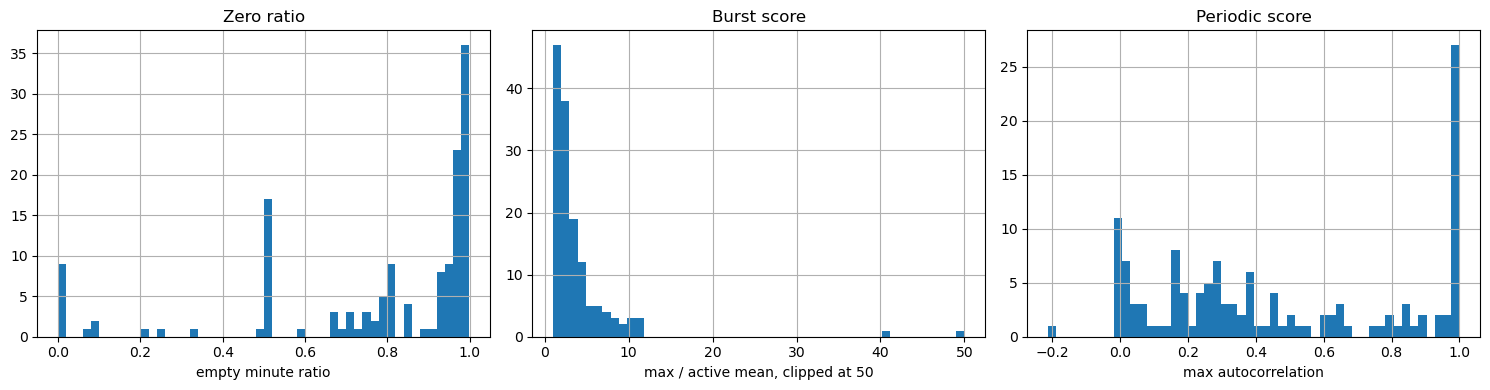

In [13]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    metrics["zero_ratio"].hist(ax=axes[0], bins=50)
    axes[0].set_title("Zero ratio")
    axes[0].set_xlabel("empty minute ratio")

    metrics["burst_score"].replace([np.inf, -np.inf], np.nan).dropna().clip(upper=50).hist(ax=axes[1], bins=50)
    axes[1].set_title("Burst score")
    axes[1].set_xlabel("max / active mean, clipped at 50")

    metrics["periodic_score"].dropna().hist(ax=axes[2], bins=50)
    axes[2].set_title("Periodic score")
    axes[2].set_xlabel("max autocorrelation")

    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("plot skipped:", type(exc).__name__, exc)